# YOLOv12 — COCO 2017 | Skripsi ELIOR
**Sesi v12** | 30 epoch | dual-T4 | nano | full COCO (118K)

Pipeline: Install → Path → Load → EDA → Convert → Symlink → YAML → Patch → Train → Eval → Zip+Link

> **Download tiap checkpoint** lewat FileLink. Kalau link mati (Kaggle kadang gitu): **Save Version → tab Output**.

## 0 — INSTALL & IMPORTS

In [1]:
import shutil
# copy metrics v11 ke working biar cell comparison bisa baca
src = '/kaggle/input/datasets/claudiojuniarto/yolov11n-metrics/yolov11n_metrics.json'
shutil.copy2(src, '/kaggle/working/yolov11n_metrics.json')
print("v11 metrics loaded")

v11 metrics loaded


In [2]:
import shutil
# copy metrics v11 ke working biar cell comparison bisa baca
src = '/kaggle/input/datasets/claudiojuniarto/yolov12-metrics/yolov12n_metrics.json'
shutil.copy2(src, '/kaggle/working/yolov12n_metrics.json')
print("v11 metrics loaded")

v11 metrics loaded


In [3]:
!pip install ultralytics supervision --quiet

import os, json, random, time, gc, warnings, glob, shutil, zipfile
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
from IPython.display import FileLink, display
import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.backends.cudnn.benchmark = True

print(f"PyTorch : {torch.__version__}")
N_GPU = torch.cuda.device_count()
print(f"GPU cnt : {N_GPU}")
for i in range(N_GPU):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)} "
          f"({torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB)")

# auto device + auto workers (bottleneck I/O symlink -> workers penting)
import psutil
DEVICE  = list(range(N_GPU)) if N_GPU > 1 else 0
WORKERS = min(psutil.cpu_count() or 4, 8)
print(f"DEVICE  : {DEVICE}")
print(f"WORKERS : {WORKERS}  (cpu_count={psutil.cpu_count()})")
print(f"RAM free: {psutil.virtual_memory().available/1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 87.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12

## 1 — HELPER: zip + download link
Dipanggil tiap checkpoint. Coba FileLink dulu, fallback ke instruksi commit.

In [ ]:
OUT = Path('/kaggle/working')

def zip_and_link(patterns, zip_name, label=""):
    files = []
    for pat in patterns:
        files += sorted(OUT.glob(pat))
    files = [f for f in dict.fromkeys(files) if f.is_file() and f.suffix != '.zip']
    if not files:
        print(f"[{label}] Tidak ada file untuk di-zip ({patterns})"); return None
    zp = OUT / zip_name
    with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
        for f in files: zf.write(f, f.name)
    print(f"\n{'='*55}\n  [{label}] ZIP: {zp.name} "
          f"({zp.stat().st_size/1e6:.1f} MB) | {len(files)} file\n{'='*55}")
    for f in files: print(f"   + {f.name}")
    print("\n  >> Klik link (kalau muncul):")
    try: display(FileLink(str(zp)))
    except Exception as e: print(f"   FileLink err: {e}")
    print(f"  >> Link mati? Save Version -> Output tab -> {zp.name}")
    return zp

## 2 — PATH CONFIG

In [4]:
COCO_ROOT = Path('/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017')
TRAIN_IMG = COCO_ROOT / 'train2017'
VAL_IMG   = COCO_ROOT / 'val2017'
TEST_IMG  = COCO_ROOT / 'test2017'
ANN_TRAIN = COCO_ROOT / 'annotations/instances_train2017.json'
ANN_VAL   = COCO_ROOT / 'annotations/instances_val2017.json'
print("Path check:")
for p in [TRAIN_IMG, VAL_IMG, TEST_IMG, ANN_TRAIN, ANN_VAL]:
    print(f"  {'OK ' if p.exists() else 'MISSING'} {p}")

Path check:
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_train2017.json
  OK  /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/instances_val2017.json


## 3 — LOAD ANNOTATIONS

In [5]:
print("Loading annotations...")
with open(ANN_TRAIN) as f: ann_train = json.load(f)
with open(ANN_VAL)   as f: ann_val   = json.load(f)
TRAIN_IMGS = ann_train['images'];  VAL_IMGS = ann_val['images']
TRAIN_ANNS = ann_train['annotations']; VAL_ANNS = ann_val['annotations']
CATEGORIES = {c['id']: c['name'] for c in ann_train['categories']}
CAT_NAMES  = [c['name'] for c in sorted(ann_train['categories'], key=lambda x: x['id'])]
print(f"  Train images : {len(TRAIN_IMGS):>8,}")
print(f"  Val   images : {len(VAL_IMGS):>8,}")
print(f"  Categories   : {len(CATEGORIES):>8}")

Loading annotations...
  Train images :  118,287
  Val   images :    5,000
  Categories   :       80


## 4 — EDA (Exploratory Data Analysis)
Semua plot disimpan ke `/kaggle/working` → masuk ke ZIP checkpoint pre-training.

In [ ]:
# 4A Category distribution
cat_counts = Counter(a['category_id'] for a in TRAIN_ANNS)
cat_df = pd.DataFrame([{'category':CATEGORIES[k],'count':v,'cat_id':k}
                       for k,v in cat_counts.items()]
                     ).sort_values('count',ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(1,2,figsize=(18,7))
ax[0].barh(cat_df['category'][:20], cat_df['count'][:20], color='#4B2FA0')
ax[0].set_title('Top 20 Categories'); ax[0].invert_yaxis()
ax[1].barh(cat_df['category'][-20:], cat_df['count'][-20:], color='#E05252')
ax[1].set_title('Bottom 20 Categories'); ax[1].invert_yaxis()
plt.tight_layout(); plt.savefig(OUT/'eda_01_category.png',dpi=120); plt.show()
print(f"Imbalance: {cat_df.iloc[0]['count']/cat_df.iloc[-1]['count']:.0f}x "
      f"({cat_df.iloc[0]['category']} vs {cat_df.iloc[-1]['category']})")

In [ ]:
# 4B Object size (penting: COCO banyak objek kecil = tantangan deteksi)
areas = [a['area'] for a in TRAIN_ANNS]
S = sum(1 for a in areas if a < 32**2)
M = sum(1 for a in areas if 32**2 <= a < 96**2)
L = sum(1 for a in areas if a >= 96**2); T = len(areas)
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].hist(areas, bins=100, color='#4B2FA0', log=True, alpha=0.85)
ax[0].set_title('BBox Area (log)'); ax[0].set_xlabel('px^2')
b = ax[1].bar(['Small\n<32px','Medium','Large\n>=96px'],[S,M,L],
              color=['#ff6b6b','#ffa94d','#69db7c'], edgecolor='black')
ax[1].set_title('Object Size Distribution')
for bar,c in zip(b,[S,M,L]):
    ax[1].text(bar.get_x()+bar.get_width()/2, bar.get_height(),
               f'{c/T*100:.1f}%', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT/'eda_02_objsize.png',dpi=120); plt.show()
print(f"Small {S/T*100:.1f}% | Medium {M/T*100:.1f}% | Large {L/T*100:.1f}%")

In [ ]:
# 4C Annotations per image
api = Counter(a['image_id'] for a in TRAIN_ANNS); counts=list(api.values())
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(counts, bins=60, color='teal', alpha=0.8)
ax.axvline(np.mean(counts), color='red', ls='--', label=f'Mean={np.mean(counts):.1f}')
ax.set_title('Annotations per Image'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'eda_03_annperimg.png',dpi=120); plt.show()
print(f"Mean {np.mean(counts):.2f} | Median {np.median(counts):.0f} | Max {max(counts)}")

In [ ]:
# 4D EDA summary + CHECKPOINT 1 (pre-training zip)
print("="*50)
print(f"  Train imgs: {len(TRAIN_IMGS):,} | Val imgs: {len(VAL_IMGS):,}")
print(f"  Classes: {len(CATEGORIES)} | Anns: {len(TRAIN_ANNS):,}")
print(f"  Small objs: {S/T*100:.1f}% (tantangan deteksi objek kecil)")
print("="*50)
zip_and_link(['eda_*.png'], 'CP1_eda_pretraining.zip', label='CP1 PRE-TRAINING')

## 5 — CONVERT COCO→YOLO + SYMLINK
Auto-detect: kalau label & symlink sudah ada (sisa sesi lalu), **skip** biar hemat ~15 menit.

In [6]:
# 5A Convert COCO JSON -> YOLO txt (auto-skip kalau sudah ada)
def coco2yolo(ann_json, label_dir):
    Path(label_dir).mkdir(parents=True, exist_ok=True)
    with open(ann_json) as f: data = json.load(f)
    info = {im['id']: im for im in data['images']}
    by_img = defaultdict(list)
    for a in data['annotations']:
        if a.get('iscrowd',0): continue
        by_img[a['image_id']].append(a)
    cat_ids = sorted(c['id'] for c in data['categories'])
    cmap = {cid:i for i,cid in enumerate(cat_ids)}
    n=0
    for iid, anns in by_img.items():
        im = info[iid]; W,H = im['width'], im['height']
        stem = Path(im['file_name']).stem
        lines=[]
        for a in anns:
            x,y,w,h = a['bbox']
            lines.append(f"{cmap[a['category_id']]} {(x+w/2)/W:.6f} {(y+h/2)/H:.6f} {w/W:.6f} {h/H:.6f}")
        with open(f"{label_dir}/{stem}.txt",'w') as f: f.write('\n'.join(lines))
        n+=1
    print(f"  Converted {n:,} -> {label_dir}")

train_lbl = Path('/kaggle/working/labels/train2017')
val_lbl   = Path('/kaggle/working/labels/val2017')
if train_lbl.exists() and len(list(train_lbl.iterdir())) > 100000:
    print(f"SKIP train convert (sudah ada {len(list(train_lbl.iterdir())):,})")
else:
    print("Converting train (~12-15 menit)..."); coco2yolo(str(ANN_TRAIN), str(train_lbl))
if val_lbl.exists() and len(list(val_lbl.iterdir())) > 4000:
    print(f"SKIP val convert (sudah ada {len(list(val_lbl.iterdir())):,})")
else:
    print("Converting val..."); coco2yolo(str(ANN_VAL), str(val_lbl))
print("Convert done.")

Converting train (~12-15 menit)...
  Converted 117,266 -> /kaggle/working/labels/train2017
Converting val...
  Converted 4,952 -> /kaggle/working/labels/val2017
Convert done.


In [7]:
# 5B Symlink images (0 GB quota, auto-skip kalau sudah ada)
from tqdm.auto import tqdm
DST_TRAIN = Path('/kaggle/working/images/train2017'); DST_TRAIN.mkdir(parents=True, exist_ok=True)
DST_VAL   = Path('/kaggle/working/images/val2017');   DST_VAL.mkdir(parents=True, exist_ok=True)

def link_dir(src, dst):
    existing = len(list(dst.glob('*.jpg')))
    src_files = list(src.glob('*.jpg'))
    if existing >= len(src_files):
        print(f"SKIP symlink {dst.name} (sudah {existing:,})"); return
    for f in tqdm(src_files, desc=f"symlink {dst.name}"):
        d = dst / f.name
        if not d.exists():
            try: os.symlink(f, d)
            except FileExistsError: pass

link_dir(TRAIN_IMG, DST_TRAIN)
link_dir(VAL_IMG, DST_VAL)
print("Symlink done.")

symlink train2017:   0%|          | 0/118287 [00:00<?, ?it/s]

symlink val2017:   0%|          | 0/5000 [00:00<?, ?it/s]

Symlink done.


In [ ]:
# 5C YAML + clear cache
import yaml as _yaml
for c in glob.glob('/kaggle/working/**/*.cache', recursive=True):
    try: os.remove(c)
    except: pass
YAML_PATH = Path('/kaggle/working/coco_direct.yaml')
with open(YAML_PATH,'w') as f:
    _yaml.dump({'path':'/kaggle/working','train':'images/train2017',
                'val':'images/val2017','nc':80,'names':CAT_NAMES}, f)
print(f"YAML -> {YAML_PATH}")

In [13]:
import yaml as _yaml

# Skip glob scan, langsung buat YAML
YAML_PATH = Path('/kaggle/working/coco_direct.yaml')
with open(YAML_PATH, 'w') as f:
    _yaml.dump({'path': '/kaggle/working', 'train': 'images/train2017',
                'val': 'images/val2017', 'nc': 80, 'names': CAT_NAMES}, f)
print(f"YAML -> {YAML_PATH}")

YAML -> /kaggle/working/coco_direct.yaml


In [14]:
# 5D PATCH img2label_paths (WAJIB tiap kernel restart, sebelum train)
import ultralytics.data.dataset as _ds
import ultralytics.data.utils as _du
_LBL = Path('/kaggle/working/labels')
def _patched(img_paths):
    out=[]
    for p in img_paths:
        p=Path(p); split='train2017' if 'train2017' in str(p) else 'val2017'
        out.append(str(_LBL/split/(p.stem+'.txt')))
    return out
_du.img2label_paths = _patched
_ds.img2label_paths = _patched
print("img2label_paths patched OK")
print("Test:", _patched(['/kaggle/working/images/train2017/000000001786.jpg']))

img2label_paths patched OK
Test: ['/kaggle/working/labels/train2017/000000001786.txt']


In [ ]:
# 5E TRANSLATE DICT (EN->ID untuk prompt BLIP nanti, bukan dipakai training)
COCO_ID = {'person':'orang','bicycle':'sepeda','car':'mobil','motorcycle':'sepeda motor',
'airplane':'pesawat','bus':'bus','train':'kereta api','truck':'truk','boat':'perahu',
'traffic light':'lampu lalu lintas','fire hydrant':'hidran kebakaran','stop sign':'rambu berhenti',
'parking meter':'meteran parkir','bench':'bangku','bird':'burung','cat':'kucing','dog':'anjing',
'horse':'kuda','sheep':'domba','cow':'sapi','elephant':'gajah','bear':'beruang','zebra':'zebra',
'giraffe':'jerapah','backpack':'ransel','umbrella':'payung','handbag':'tas tangan','tie':'dasi',
'suitcase':'koper','frisbee':'frisbee','skis':'ski','snowboard':'papan salju','sports ball':'bola olahraga',
'kite':'layang-layang','baseball bat':'tongkat bisbol','baseball glove':'sarung tangan bisbol',
'skateboard':'skateboard','surfboard':'papan selancar','tennis racket':'raket tenis','bottle':'botol',
'wine glass':'gelas anggur','cup':'cangkir','fork':'garpu','knife':'pisau','spoon':'sendok','bowl':'mangkuk',
'banana':'pisang','apple':'apel','sandwich':'roti lapis','orange':'jeruk','broccoli':'brokoli','carrot':'wortel',
'hot dog':'sosis','pizza':'pizza','donut':'donat','cake':'kue','chair':'kursi','couch':'sofa',
'potted plant':'tanaman pot','bed':'tempat tidur','dining table':'meja makan','toilet':'toilet','tv':'televisi',
'laptop':'laptop','mouse':'tetikus','remote':'remote','keyboard':'keyboard','cell phone':'ponsel',
'microwave':'microwave','oven':'oven','toaster':'pemanggang roti','sink':'wastafel','refrigerator':'kulkas',
'book':'buku','clock':'jam','vase':'vas bunga','scissors':'gunting','teddy bear':'boneka beruang',
'hair drier':'pengering rambut','toothbrush':'sikat gigi'}
def build_prompt_id(dets):
    if not dets: return "sebuah gambar"
    cnt = Counter(COCO_ID.get(d,d) for d in dets)
    parts=[f"{c} {o}" for o,c in cnt.items()]
    if len(parts)==1: desc=parts[0]
    elif len(parts)==2: desc=f"{parts[0]} dan {parts[1]}"
    else: desc=", ".join(parts[:-1])+f", dan {parts[-1]}"
    return f"sebuah foto yang menampilkan {desc}"
miss=[n for n in CAT_NAMES if n not in COCO_ID]
print(f"Coverage {len(COCO_ID)}/80 | Missing: {miss if miss else 'None'}")
print("Test:", build_prompt_id(['car','person','car','dog']))

## 6 — YOLOv12 MODEL INFO

In [ ]:
MODEL_NAME = 'yolov12n'
WEIGHTS    = 'yolo12n.pt'
EPOCHS     = 30
IMG_SIZE   = 640
BATCH      = 96
NBS        = 128

gc.collect(); torch.cuda.empty_cache()
for i in range(N_GPU): torch.cuda.reset_peak_memory_stats(i)
m = YOLO(WEIGHTS); m.model.to('cuda')
m.info(verbose=False)
del m; torch.cuda.empty_cache(); gc.collect()
for i in range(N_GPU):
    print(f"GPU {i} free: {torch.cuda.mem_get_info(i)[0]/1e9:.2f} GB")

In [ ]:
# FlashAttention check (T4 = compute 7.5 = supported, else fallback otomatis)
cap = torch.cuda.get_device_capability()
print(f"GPU {torch.cuda.get_device_name(0)} | compute {cap[0]}.{cap[1]}")
print("FlashAttn:", "supported" if cap[0]>=7 else "fallback (tetap jalan, lebih lambat)")

## 7 — YOLOv12 TRAINING (30 epoch)
`save_period=5` → best.pt & last.pt auto-save tiap 5 epoch (aman dari timeout).
Callback backup ekstra copy best.pt ke `/working` root tiap 5 epoch.

**Resume**: kalau sesi mati lalu restart, jalankan ulang setup (cell 0-5) lalu set `RESUME=True` di bawah → lanjut dari last.pt.

In [ ]:
RESUME = False   # set True kalau melanjutkan training yang terputus

def backup_cb(trainer):
    ep = trainer.epoch + 1
    if ep % 5 == 0:
        wd = Path(trainer.save_dir)/'weights'
        for fn in ['best.pt','last.pt']:
            p = wd/fn
            if p.exists(): shutil.copy2(p, OUT/f'SAVE_{MODEL_NAME}_{fn}')
        csv = Path(trainer.save_dir)/'results.csv'
        if csv.exists(): shutil.copy2(csv, OUT/f'SAVE_{MODEL_NAME}_results.csv')
        print(f"  [backup] epoch {ep} -> SAVE_{MODEL_NAME}_*.pt")

last_pt = OUT/'runs'/MODEL_NAME/'weights'/'last.pt'
if RESUME and last_pt.exists():
    print(f"RESUME dari {last_pt}"); model = YOLO(str(last_pt))
else:
    model = YOLO(WEIGHTS)
model.add_callback('on_train_epoch_end', backup_cb)

for i in range(N_GPU): torch.cuda.reset_peak_memory_stats(i)
t0 = time.time()
results = model.train(
    data=str(YAML_PATH), epochs=EPOCHS, imgsz=IMG_SIZE,
    batch=BATCH, nbs=NBS, workers=WORKERS, device=DEVICE,
    project=str(OUT/'runs'), name=MODEL_NAME, exist_ok=True,
    seed=SEED, cache=False, amp=True, cos_lr=True,
    warmup_epochs=3, multi_scale=False, plots=True,
    close_mosaic=10, patience=20, save_period=5,
    iou=0.6,          # NMS lebih longgar -> objek overlap (kursi dll) lebih banyak kedeteksi
    resume=(RESUME and last_pt.exists()), verbose=True,
)
t1 = time.time()
train_hrs = (t1-t0)/3600
mem = [torch.cuda.max_memory_allocated(i)/1e9 for i in range(N_GPU)]
print(f"\n{MODEL_NAME} DONE | {train_hrs:.2f} jam | VRAM {['%.1f'%x for x in mem]}")
del model; gc.collect(); torch.cuda.empty_cache()

In [ ]:
# cek best.pt ada
import os
print(os.path.exists('/kaggle/working/SAVE_yolov12n_best.pt'))
print(os.path.exists('/kaggle/working/runs/yolov12n/weights/best.pt'))

## 8 — YOLOv12 VALIDATION

In [ ]:
best = OUT/'runs'/MODEL_NAME/'weights'/'best.pt'
assert best.exists(), "best.pt tidak ada!"
model = YOLO(str(best))
mt = model.val(data=str(YAML_PATH), imgsz=IMG_SIZE, batch=BATCH,
               device=0, verbose=False, split='val', iou=0.7)  # default, comparable v11 & paper
val_metrics = {
  'model': MODEL_NAME,
  'mAP50': float(mt.box.map50), 'mAP50_95': float(mt.box.map),
  'precision': float(mt.box.mp), 'recall': float(mt.box.mr),
  'train_hrs': round(train_hrs,2),
  'per_class_ap50': {CAT_NAMES[int(i)]: float(v)
        for i,v in zip(mt.box.ap_class_index, mt.box.ap50)},
}
print(f"mAP@0.5      : {val_metrics['mAP50']:.4f}")
print(f"mAP@0.5:0.95 : {val_metrics['mAP50_95']:.4f}")
print(f"Precision    : {val_metrics['precision']:.4f}")
print(f"Recall       : {val_metrics['recall']:.4f}")
del model; torch.cuda.empty_cache(); gc.collect()

In [17]:
IMG_SIZE = 640
BATCH = 64
MODEL_NAME = 'yolov12n'

best = Path('/kaggle/input/datasets/claudiojuniarto/yolov12-metrics/yolov12n_best.pt')
assert best.exists(), "best.pt tidak ada!"
model = YOLO(str(best))
mt = model.val(data=str(YAML_PATH), imgsz=IMG_SIZE, batch=BATCH,
               device=0, verbose=False, split='val', iou=0.7)
train_hrs = 11.0
val_metrics = {
  'model': MODEL_NAME,
  'mAP50': float(mt.box.map50), 'mAP50_95': float(mt.box.map),
  'precision': float(mt.box.mp), 'recall': float(mt.box.mr),
  'train_hrs': train_hrs,
  'per_class_ap50': {CAT_NAMES[int(i)]: float(v)
        for i,v in zip(mt.box.ap_class_index, mt.box.ap50)},
}
print(f"mAP@0.5      : {val_metrics['mAP50']:.4f}")
print(f"mAP@0.5:0.95 : {val_metrics['mAP50_95']:.4f}")
print(f"Precision    : {val_metrics['precision']:.4f}")
print(f"Recall       : {val_metrics['recall']:.4f}")
del model; torch.cuda.empty_cache(); gc.collect()

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,590,824 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.1±5.0 MB/s, size: 141.0 KB)
val: Scanning /kaggle/working/labels/val2017... 4952 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 328.7it/s 15.2s<0.0s
val: New cache created: /kaggle/working/labels/val2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 79/79 1.1it/s 1:110.5sss
                   all       5000      36335      0.637      0.503      0.539      0.382
Speed: 0.7ms preprocess, 9.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@0.5      : 0.5386
mAP@0.5:0.95 : 0.3821
Precision    : 0.6365
Recall       : 0.5027


93101

In [ ]:
train_hrs = 11.0  # estimasi aktual lo (stop di ~11 jam)

val_metrics = {
  'model': MODEL_NAME,
  'mAP50': float(mt.box.map50), 'mAP50_95': float(mt.box.map),
  'precision': float(mt.box.mp), 'recall': float(mt.box.mr),
  'train_hrs': train_hrs,
  'per_class_ap50': {CAT_NAMES[int(i)]: float(v)
        for i,v in zip(mt.box.ap_class_index, mt.box.ap50)},
}
print(f"mAP@0.5      : {val_metrics['mAP50']:.4f}")
print(f"mAP@0.5:0.95 : {val_metrics['mAP50_95']:.4f}")
print(f"Precision    : {val_metrics['precision']:.4f}")
print(f"Recall       : {val_metrics['recall']:.4f}")

In [ ]:
best = OUT/'runs'/MODEL_NAME/'weights'/'best.pt'
assert best.exists(), "best.pt tidak ada!"
model = YOLO(str(best))
mt = model.val(data=str(YAML_PATH), imgsz=IMG_SIZE, batch=BATCH,
               device=0, verbose=False, split='val', iou=0.7)

## 9 — YOLOv12 SPEED BENCHMARK

In [19]:
test_imgs = list(VAL_IMG.glob('*.jpg'))[:300]
model = YOLO(str(best))
for _ in range(5): _ = model(str(test_imgs[0]), verbose=False)
torch.cuda.synchronize(); t0=time.time()
for _ in model(test_imgs, verbose=False, stream=True): pass
torch.cuda.synchronize(); t1=time.time()
avg_ms = (t1-t0)/len(test_imgs)*1000
speed_metrics = {'avg_inference_ms':round(avg_ms,2),'fps':round(1000/avg_ms,1),
                  'n_images':len(test_imgs)}
print(f"{MODEL_NAME}: {avg_ms:.2f} ms | {1000/avg_ms:.1f} FPS")
del model; torch.cuda.empty_cache(); gc.collect()

yolov12n: 36.43 ms | 27.5 FPS


5404

In [ ]:
# ── DEPLOYMENT CONFIG untuk ELIOR app (bukan untuk eval) ──────────────────
# conf+iou rendah = recall tinggi = lebih banyak objek kedeteksi
# termasuk objek overlap: kursi banyak, kerumunan orang, dll

DEPLOY_CONF = 0.20   # default 0.25 -> turunin biar deteksi lebih banyak
DEPLOY_IOU  = 0.45   # default 0.7  -> turunin biar overlap lolos NMS

def detect_for_elior(img_path, model_path, conf=DEPLOY_CONF, iou=DEPLOY_IOU):
    m = YOLO(str(model_path))
    res = m(str(img_path), conf=conf, iou=iou, agnostic_nms=True, verbose=False)[0]
    labels = [m.names[int(c)] for c in res.boxes.cls]
    prompt = build_prompt_id(labels)
    print(f"Deteksi ({len(labels)} objek): {labels}")
    print(f"Prompt BLIP : {prompt}")
    del m; torch.cuda.empty_cache()
    return labels, prompt

# Test 1 gambar (jalankan setelah training selesai)
sample = list(VAL_IMG.glob('*.jpg'))[0]
bv12   = OUT/'runs'/MODEL_NAME/'weights'/'best.pt'
if bv12.exists():
    detect_for_elior(sample, bv12)
else:
    print("Jalankan cell ini setelah training selesai")

## 10 — YOLOv12 TRAINING CURVES + PER-CLASS + PREDIKSI

In [ ]:
# Training curves
df = pd.read_csv(OUT/'runs'/MODEL_NAME/'results.csv'); df.columns=df.columns.str.strip()
fig, ax = plt.subplots(2,3,figsize=(18,9))
fig.suptitle(f'{MODEL_NAME} Training Curves', fontweight='bold')
specs=[('train/box_loss','val/box_loss','Box Loss'),
       ('train/cls_loss','val/cls_loss','Cls Loss'),
       ('train/dfl_loss','val/dfl_loss','DFL Loss'),
       ('metrics/mAP50(B)',None,'mAP@0.5'),
       ('metrics/mAP50-95(B)',None,'mAP@0.5:0.95'),
       ('metrics/recall(B)',None,'Recall')]
for a,(ct,cv,lb) in zip(ax.flat,specs):
    if ct in df: a.plot(df['epoch'],df[ct],label='train',color='#4B2FA0')
    if cv and cv in df: a.plot(df['epoch'],df[cv],label='val',color='coral',ls='--')
    a.set_title(lb); a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_curves.png',dpi=120); plt.show()

In [ ]:
# Per-class mAP (lihat kelas common: person/chair/car penting buat ELIOR)
pc = pd.DataFrame(val_metrics['per_class_ap50'].items(),
                  columns=['class','ap50']).sort_values('ap50')
fig, ax = plt.subplots(1,2,figsize=(18,8))
fig.suptitle(f'{MODEL_NAME} Per-Class mAP@0.5', fontweight='bold')
ax[0].barh(pc['class'][-20:], pc['ap50'][-20:], color='#4B2FA0')
ax[0].set_title('Top 20'); ax[0].set_xlim(0,1)
ax[1].barh(pc['class'][:20], pc['ap50'][:20], color='#E05252')
ax[1].set_title('Bottom 20'); ax[1].set_xlim(0,1)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_perclass.png',dpi=120); plt.show()

In [ ]:
# Visual prediction sample
model = YOLO(str(best))
imgs = random.sample(list(VAL_IMG.glob('*.jpg')), 6)
fig, ax = plt.subplots(2,3,figsize=(16,10))
fig.suptitle(f'{MODEL_NAME} Predictions', fontweight='bold')
for a,p in zip(ax.flat, imgs):
    r = model(str(p), verbose=False)[0]
    a.imshow(r.plot(labels=True, conf=True)[:,:,::-1]); a.axis('off')
    a.set_title(f"{len(r.boxes) if r.boxes else 0} deteksi", fontsize=9)
plt.tight_layout(); plt.savefig(OUT/f'{MODEL_NAME}_predictions.png',dpi=100); plt.show()
del model; torch.cuda.empty_cache(); gc.collect()

## 11 — SAVE METRICS JSON + CHECKPOINT 2 (download v12)
Metrics disimpan ke JSON di disk → dibaca cell comparison (tahan restart kernel).

In [ ]:
# copy weight + results ke root, simpan metrics ke JSON
wd = OUT/'runs'/MODEL_NAME/'weights'
for w in wd.glob('*.pt'): shutil.copy2(w, OUT/f'{MODEL_NAME}_{w.name}')
shutil.copy2(OUT/'runs'/MODEL_NAME/'results.csv', OUT/f'{MODEL_NAME}_results.csv')

full = {'val':val_metrics, 'speed':speed_metrics}
with open(OUT/f'{MODEL_NAME}_metrics.json','w') as f: json.dump(full, f, indent=2)
print("Saved:", OUT/f'{MODEL_NAME}_metrics.json')

zip_and_link(
    [f'{MODEL_NAME}_*.pt', f'{MODEL_NAME}_*.csv', f'{MODEL_NAME}_*.png',
     f'{MODEL_NAME}_metrics.json'],
    f'CP2_{MODEL_NAME}_full.zip', label=f'CP2 {MODEL_NAME.upper()}')

In [23]:
import json, shutil
from pathlib import Path

OUT = Path('/kaggle/working')
MODEL_NAME = 'yolov12n'

# Skip copy weight/results.csv (tidak ada dari val-only run)
# Langsung save metrics JSON
full = {'val': val_metrics, 'speed': speed_metrics}
with open(OUT / f'{MODEL_NAME}_metrics.json', 'w') as f:
    json.dump(full, f, indent=2)
print("Saved:", OUT / f'{MODEL_NAME}_metrics.json')

Saved: /kaggle/working/yolov12n_metrics.json


## 12 — COMPARISON v11 vs v12
**Baca metrics dari JSON di disk** (bukan variabel memori) → tetap jalan walau v11 ditraining di sesi terpisah.

Pastikan `yolov11n_metrics.json` DAN `yolov12n_metrics.json` ada di `/kaggle/working` (upload hasil sesi v11 sebagai dataset, atau jalankan di sesi yang sama).

In [24]:
# Load kedua metrics JSON
ALL_VAL, ALL_SPEED = {}, {}
for mn in ['yolov11n','yolov12n']:
    jp = OUT/f'{mn}_metrics.json'
    if jp.exists():
        d = json.load(open(jp))
        ALL_VAL[mn]=d['val']; ALL_SPEED[mn]=d['speed']
        print(f"Loaded {mn}: mAP50={d['val']['mAP50']:.4f}")
    else:
        print(f"MISSING {jp} -- upload metrics sesi {mn} dulu")
assert len(ALL_VAL)>=1, "Tidak ada metrics untuk dibandingkan"
models_list = list(ALL_VAL.keys())

Loaded yolov11n: mAP50=0.5230
Loaded yolov12n: mAP50=0.5386


In [25]:
# Tabel ringkas
rows=[]
for m in models_list:
    v=ALL_VAL[m]; s=ALL_SPEED[m]
    rows.append({'model':m,'mAP@0.5':round(v['mAP50'],4),'mAP@0.5:0.95':round(v['mAP50_95'],4),
                 'precision':round(v['precision'],4),'recall':round(v['recall'],4),
                 'ms':s['avg_inference_ms'],'fps':s['fps'],'train_hrs':v.get('train_hrs','-')})
df_final = pd.DataFrame(rows)
print(df_final.to_string(index=False))
df_final.to_csv(OUT/'final_benchmark.csv', index=False)

   model  mAP@0.5  mAP@0.5:0.95  precision  recall    ms  fps  train_hrs
yolov11n   0.5230        0.3700     0.6296  0.4821 14.27 70.1      10.55
yolov12n   0.5386        0.3821     0.6365  0.5027 36.43 27.5      11.00


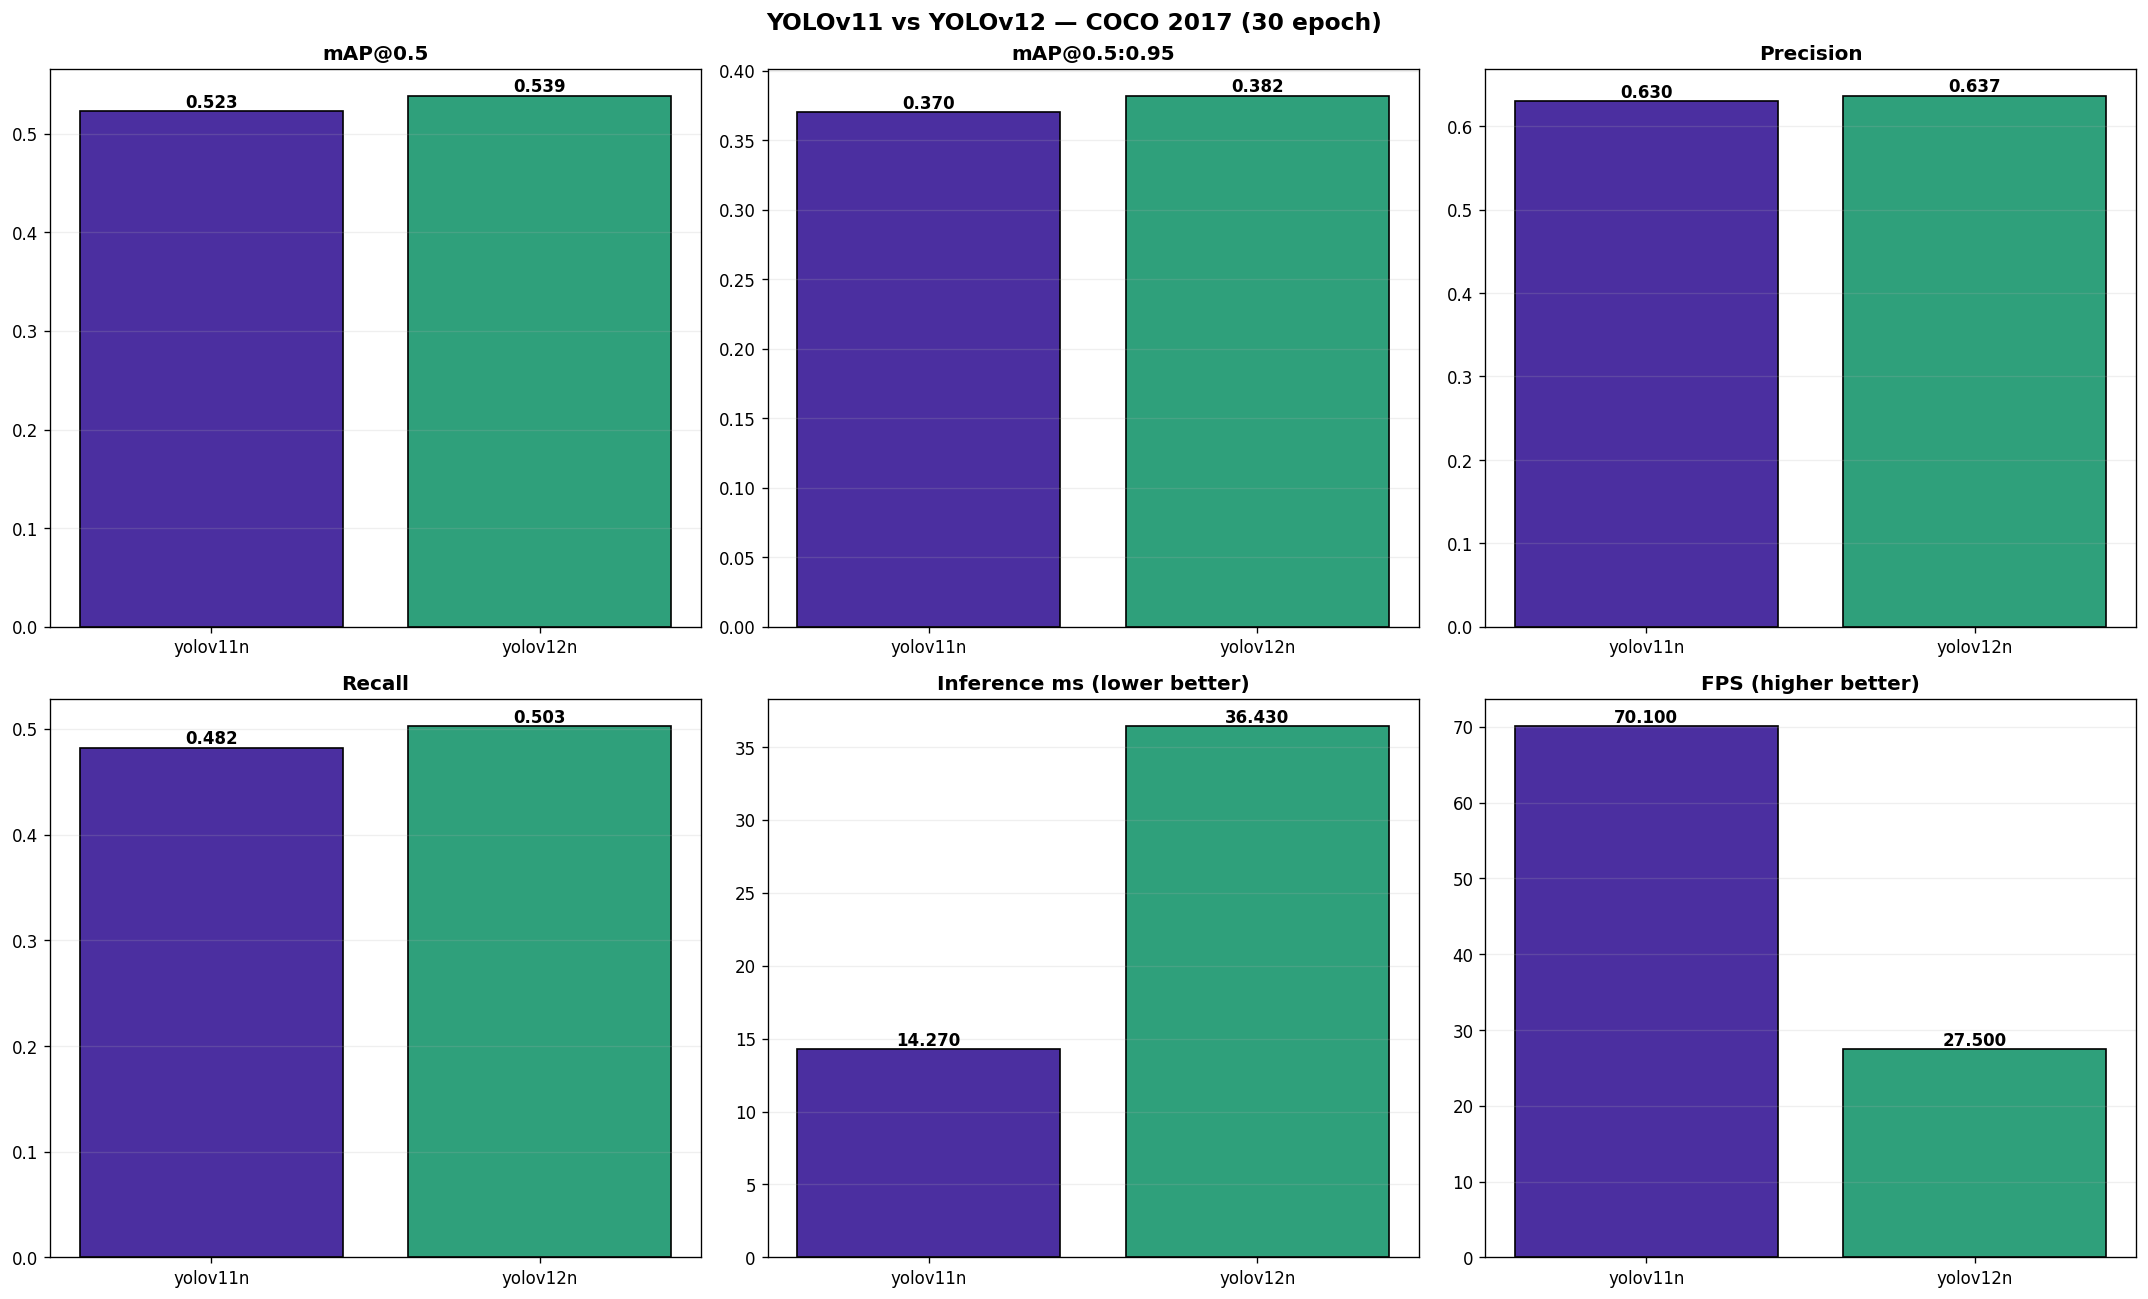

In [26]:
# Bar chart semua metrik
bar_colors=['#4B2FA0','#2FA07B','#7B5FD0','#5FD0A0']
fig, ax = plt.subplots(2,3,figsize=(18,11))
fig.suptitle('YOLOv11 vs YOLOv12 — COCO 2017 (30 epoch)', fontsize=14, fontweight='bold')
specs=[('mAP50','mAP@0.5',ALL_VAL),('mAP50_95','mAP@0.5:0.95',ALL_VAL),
       ('precision','Precision',ALL_VAL),('recall','Recall',ALL_VAL),
       ('avg_inference_ms','Inference ms (lower better)',ALL_SPEED),('fps','FPS (higher better)',ALL_SPEED)]
for a,(k,lb,src) in zip(ax.flat,specs):
    mods=[m for m in models_list if m in src]; vals=[src[m][k] for m in mods]
    b=a.bar(mods,vals,color=bar_colors[:len(mods)],edgecolor='black')
    a.set_title(lb,fontweight='bold'); a.grid(alpha=0.2,axis='y')
    for bar,v in zip(b,vals): a.text(bar.get_x()+bar.get_width()/2,bar.get_height(),
                                      f'{v:.3f}',ha='center',va='bottom',fontweight='bold')
plt.tight_layout(); plt.savefig(OUT/'comparison_all_metrics.png',dpi=150); plt.show()

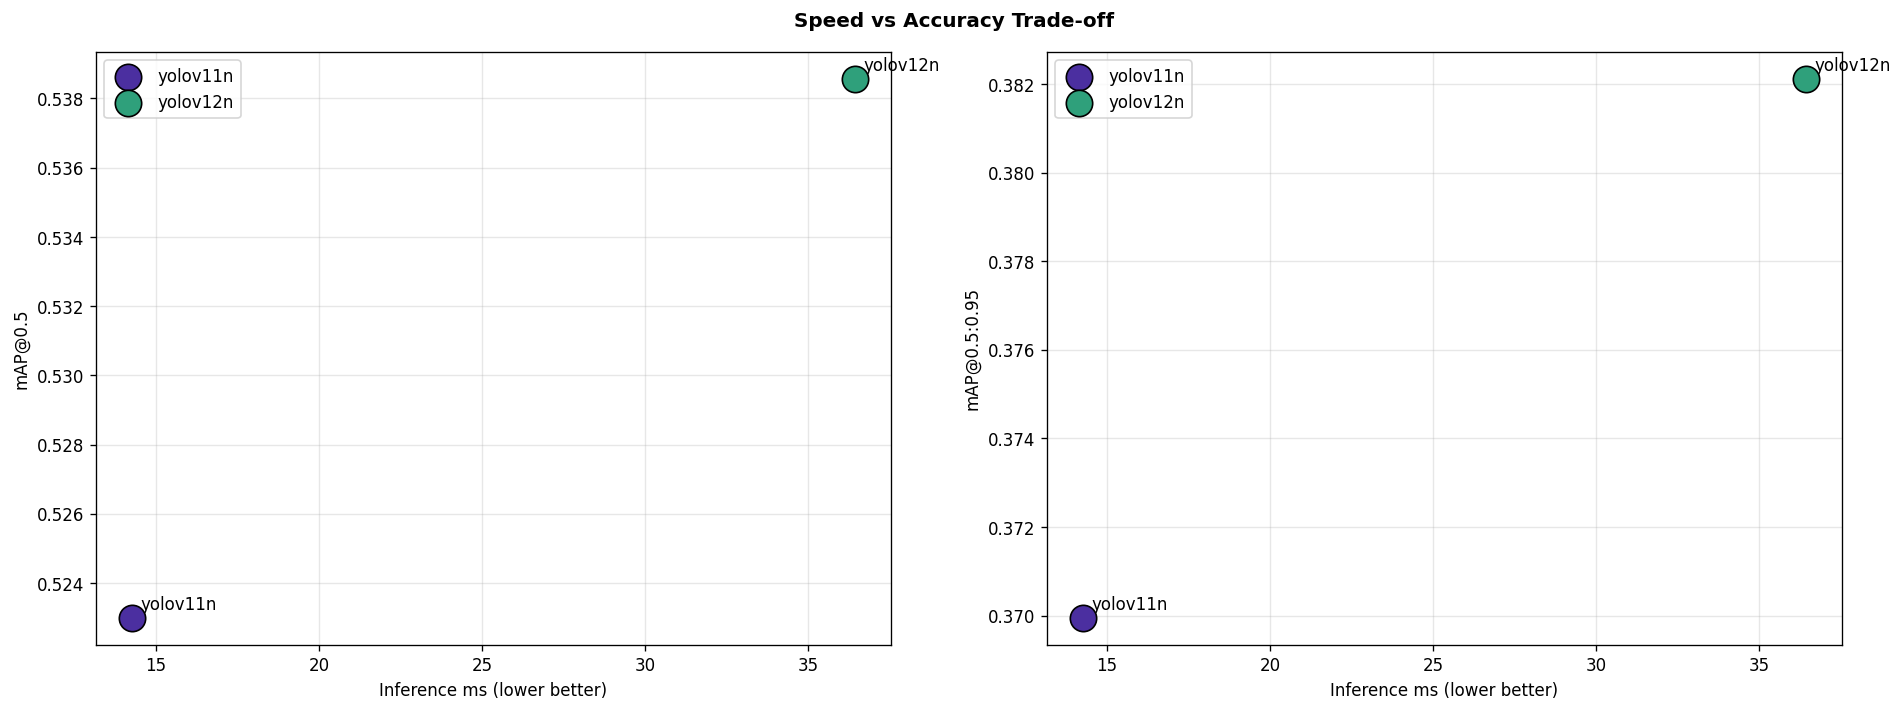

In [27]:
# Speed vs accuracy scatter
fig, ax = plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Speed vs Accuracy Trade-off', fontweight='bold')
for a,(yk,yl) in zip(ax,[('mAP50','mAP@0.5'),('mAP50_95','mAP@0.5:0.95')]):
    for m,c in zip(models_list,bar_colors):
        if m in ALL_VAL and m in ALL_SPEED:
            x=ALL_SPEED[m]['avg_inference_ms']; y=ALL_VAL[m][yk]
            a.scatter(x,y,s=250,color=c,edgecolors='black',zorder=5,label=m)
            a.annotate(m,(x,y),xytext=(5,5),textcoords='offset points')
    a.set_xlabel('Inference ms (lower better)'); a.set_ylabel(yl); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/'speed_accuracy_scatter.png',dpi=150); plt.show()

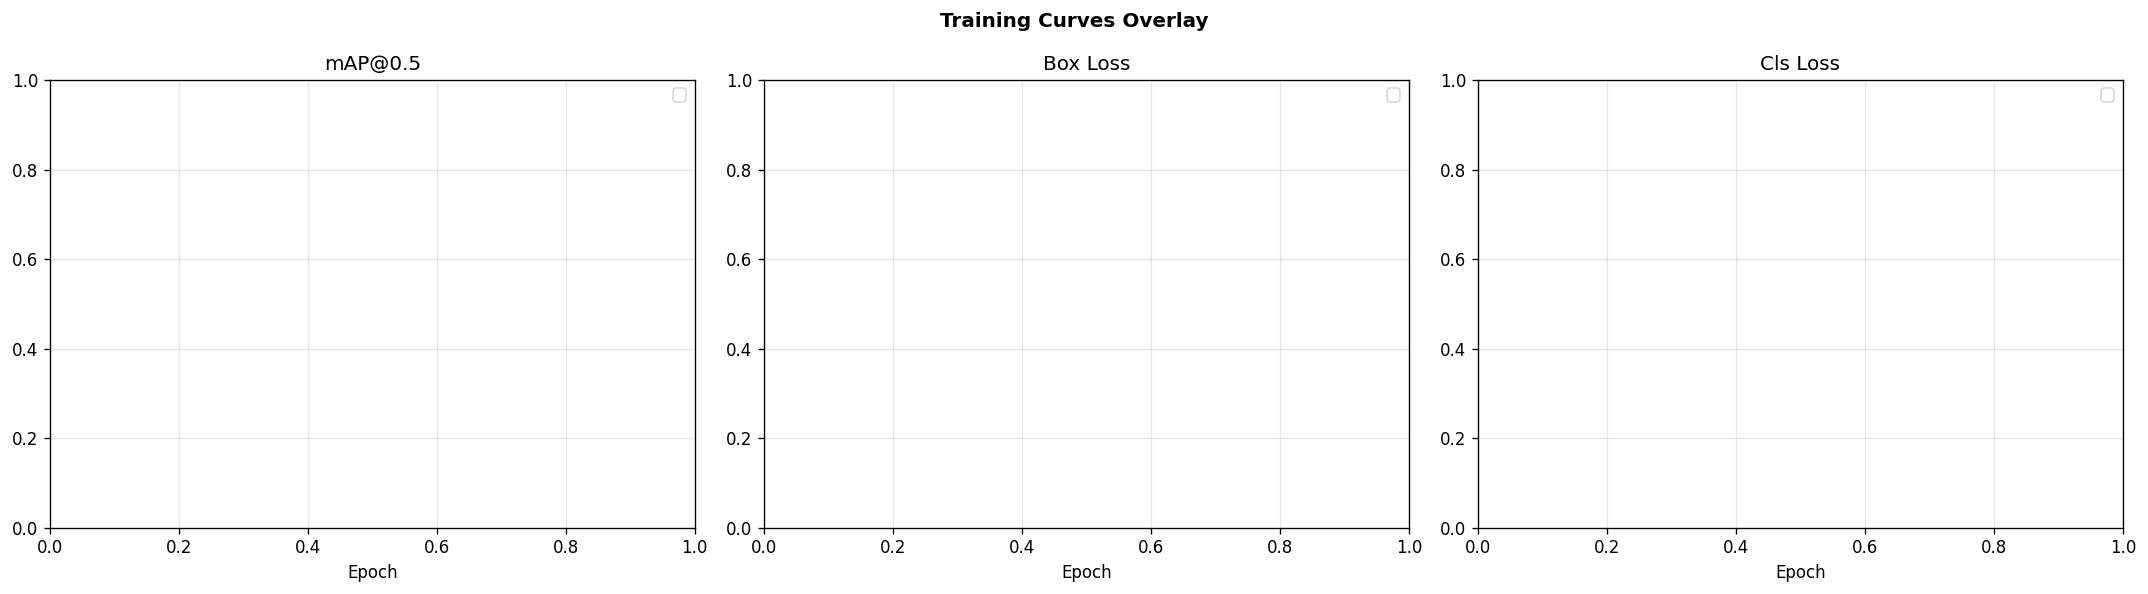

In [28]:
# Overlay training curves v11 vs v12 (kalau dua results.csv ada)
fig, ax = plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Training Curves Overlay', fontweight='bold')
cmap={'yolov11n':'#4B2FA0','yolov12n':'#2FA07B'}
specs=[('metrics/mAP50(B)','mAP@0.5'),('train/box_loss','Box Loss'),('train/cls_loss','Cls Loss')]
for a,(col,lb) in zip(ax,specs):
    for m in models_list:
        csv = OUT/f'{m}_results.csv'
        if not csv.exists(): csv = OUT/'runs'/m/'results.csv'
        if csv.exists():
            d=pd.read_csv(csv); d.columns=d.columns.str.strip()
            if col in d: a.plot(d['epoch'],d[col],label=m,color=cmap.get(m),lw=2)
    a.set_title(lb); a.set_xlabel('Epoch'); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT/'overlay_curves.png',dpi=120); plt.show()

In [29]:
# Winner (composite score) + rekomendasi BLIP
scores={}
for m in models_list:
    ns=[]
    for k in ['mAP50','mAP50_95','precision','recall']:
        allv=[ALL_VAL[x][k] for x in models_list]
        ns.append(ALL_VAL[m][k]/max(allv))
    fps_all=[ALL_SPEED[x]['fps'] for x in models_list]
    ns.append(ALL_SPEED[m]['fps']/max(fps_all))
    scores[m]=np.mean(ns)
winner=max(scores,key=scores.get)
print("="*55); print("  COMPOSITE SCORE (mAP50+mAP50_95+P+R+FPS, equal weight)"); print("="*55)
for m,s in sorted(scores.items(),key=lambda x:-x[1]):
    print(f"  {m:<12}: {s:.4f}{'  <- WINNER' if m==winner else ''}")
print(f"\n  >> MODEL UNTUK PIPELINE BLIP: {winner}")
v=ALL_VAL[winner]; sp=ALL_SPEED[winner]
print(f"     mAP@0.5={v['mAP50']:.4f} | recall={v['recall']:.4f} | {sp['fps']:.1f} FPS")
print("     (recall penting: objek kelewat lebih buruk dari false positive utk tunanetra)")

  COMPOSITE SCORE (mAP50+mAP50_95+P+R+FPS, equal weight)
  yolov11n    : 0.9775  <- WINNER
  yolov12n    : 0.8785

  >> MODEL UNTUK PIPELINE BLIP: yolov11n
     mAP@0.5=0.5230 | recall=0.4821 | 70.1 FPS
     (recall penting: objek kelewat lebih buruk dari false positive utk tunanetra)


## 13 — FINAL CHECKPOINT (download semua)

In [ ]:
zip_and_link(
    ['comparison_*.png','speed_accuracy_*.png','overlay_*.png','final_benchmark.csv',
     'yolov11n_metrics.json','yolov12n_metrics.json',
     'yolov11n_best.pt','yolov12n_best.pt'],
    'CP3_FINAL_comparison.zip', label='CP3 FINAL')
print("\nSELESAI. best.pt pemenang = input untuk fine-tuning prompt BLIP-2.")